In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Cars.csv")
df.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [7]:
df.mean()

HP     117.469136
MPG     34.422076
VOL     98.765432
SP     121.540272
WT      32.412577
dtype: float64

In [8]:
df.median()

HP     100.000000
MPG     35.152727
VOL    101.000000
SP     118.208698
WT      32.734518
dtype: float64

In [12]:
from scipy.stats import mode
mode(df,keepdims=True).mode[0] ### Similarly we can do for 

ModeResult(mode=array([[ 92.        ,  29.62993595,  50.        , 118.2889958 ,
         15.71285853]]), count=array([[7., 5., 9., 4., 1.]]))

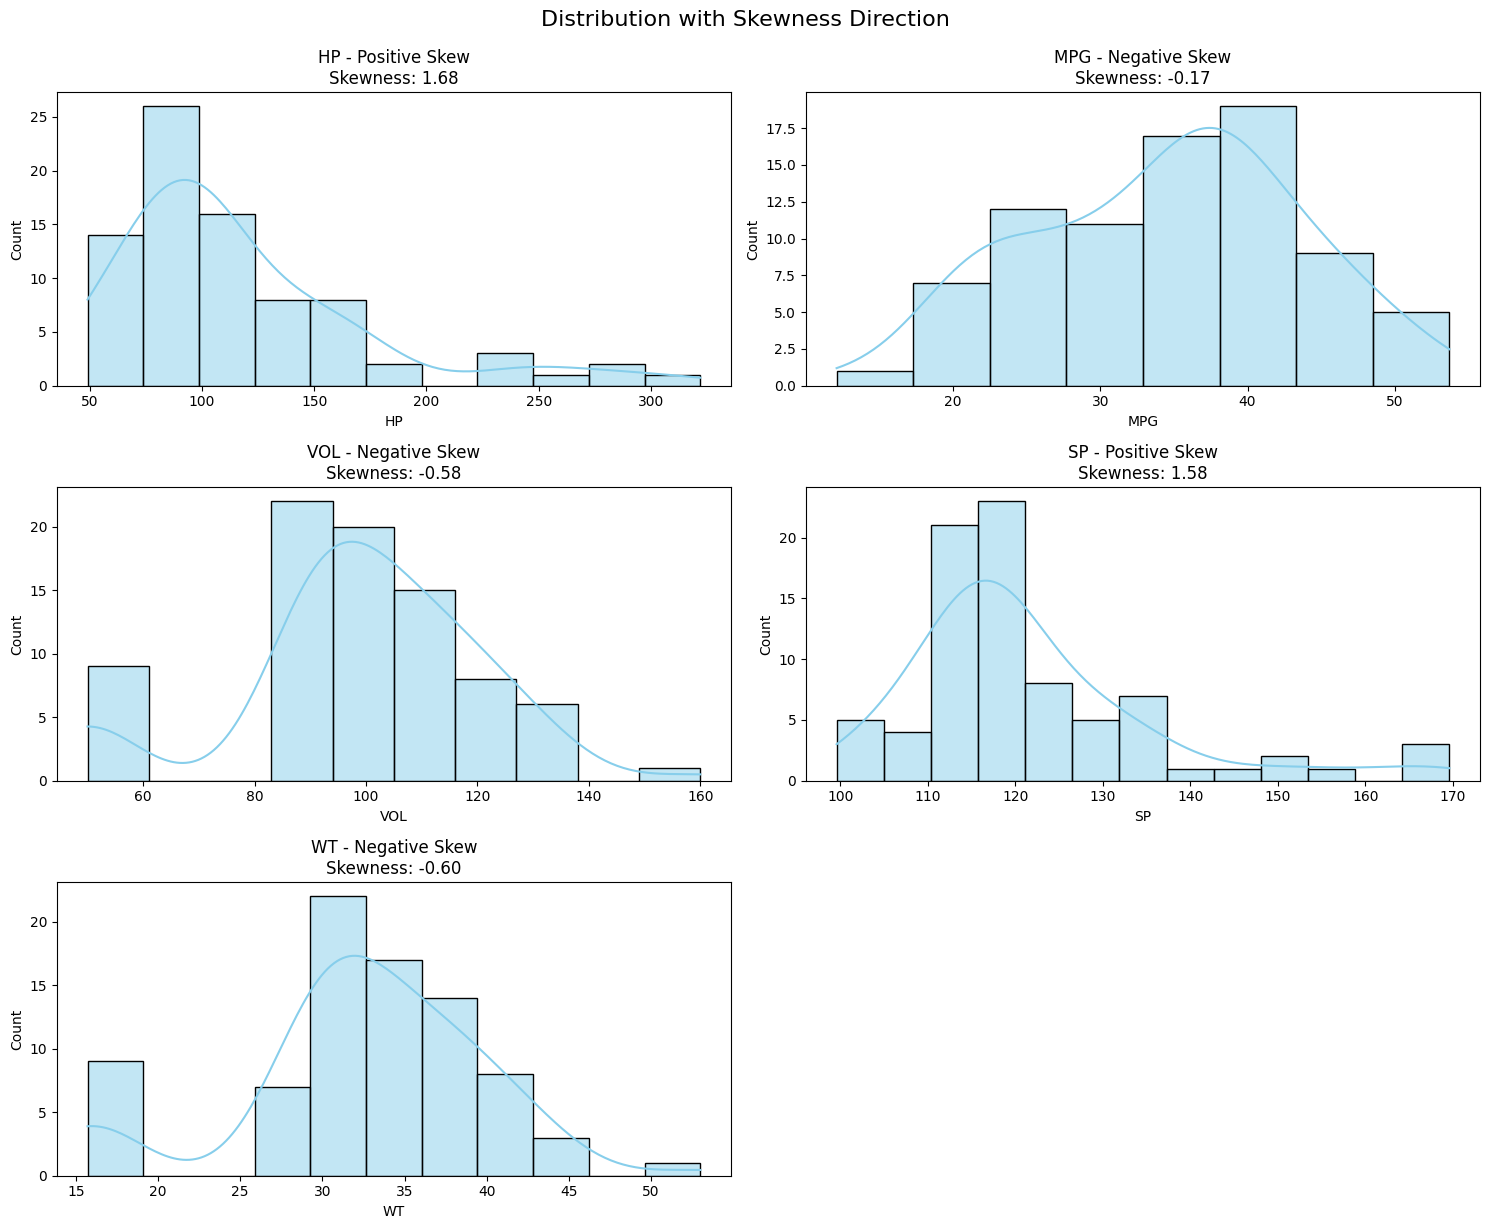

,Mean,Median,Mode,Variance,Standard Deviation,Range,Skewness,Kurtosis
HP,117.469,100.000,92.000,3261.952,57.114,273.000,1.684,2.707
MPG,34.422,35.153,29.630,83.383,9.131,41.599,-0.175,-0.648
VOL,98.765,101.000,50.000,497.357,22.301,110.000,-0.579,0.791
SP,121.540,118.209,118.289,201.113,14.181,70.034,1.581,2.724
WT,32.413,32.735,15.713,56.142,7.493,37.285,-0.603,0.819


In [4]:
#Business Moments
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, mode

# Load dataset
df = pd.read_csv("Cars.csv")

# Select relevant numerical columns
num_cols = ['HP', 'MPG', 'VOL', 'SP', 'WT']
data = df[num_cols]

# Initialize dictionary to store results
results = {}

# Compute all required statistics
for col in num_cols:
    col_data = data[col]
    results[col] = {
        "Mean": col_data.mean(),
        "Median": col_data.median(),
        "Mode": mode(col_data, keepdims=True).mode[0],
        "Variance": col_data.var(),
        "Standard Deviation": col_data.std(),
        "Range": col_data.max() - col_data.min(),
        "Skewness": skew(col_data),
        "Kurtosis": kurtosis(col_data)
    }

# Convert results to DataFrame
summary_df = pd.DataFrame(results).T.round(3)

# Plot histograms with skewness direction
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='skyblue')
    skewness = summary_df.loc[col, "Skewness"]
    skew_text = "Positive Skew" if skewness > 0 else "Negative Skew" if skewness < 0 else "Symmetric"
    axes[i].set_title(f"{col} - {skew_text}\nSkewness: {skewness:.2f}")

# Remove any empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle("Distribution with Skewness Direction", fontsize=16, y=1.02)
plt.show()

summary_df


C:\Users\rajashekarm\AppData\Local\Temp\ipykernel_26180\135518211.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mpg_by_hp = df.groupby('HP_Bucket')['MPG'].mean().reset_index()
C:\Users\rajashekarm\AppData\Local\Temp\ipykernel_26180\135518211.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HP_Bucket', y='MPG', data=mpg_by_hp, palette='viridis')


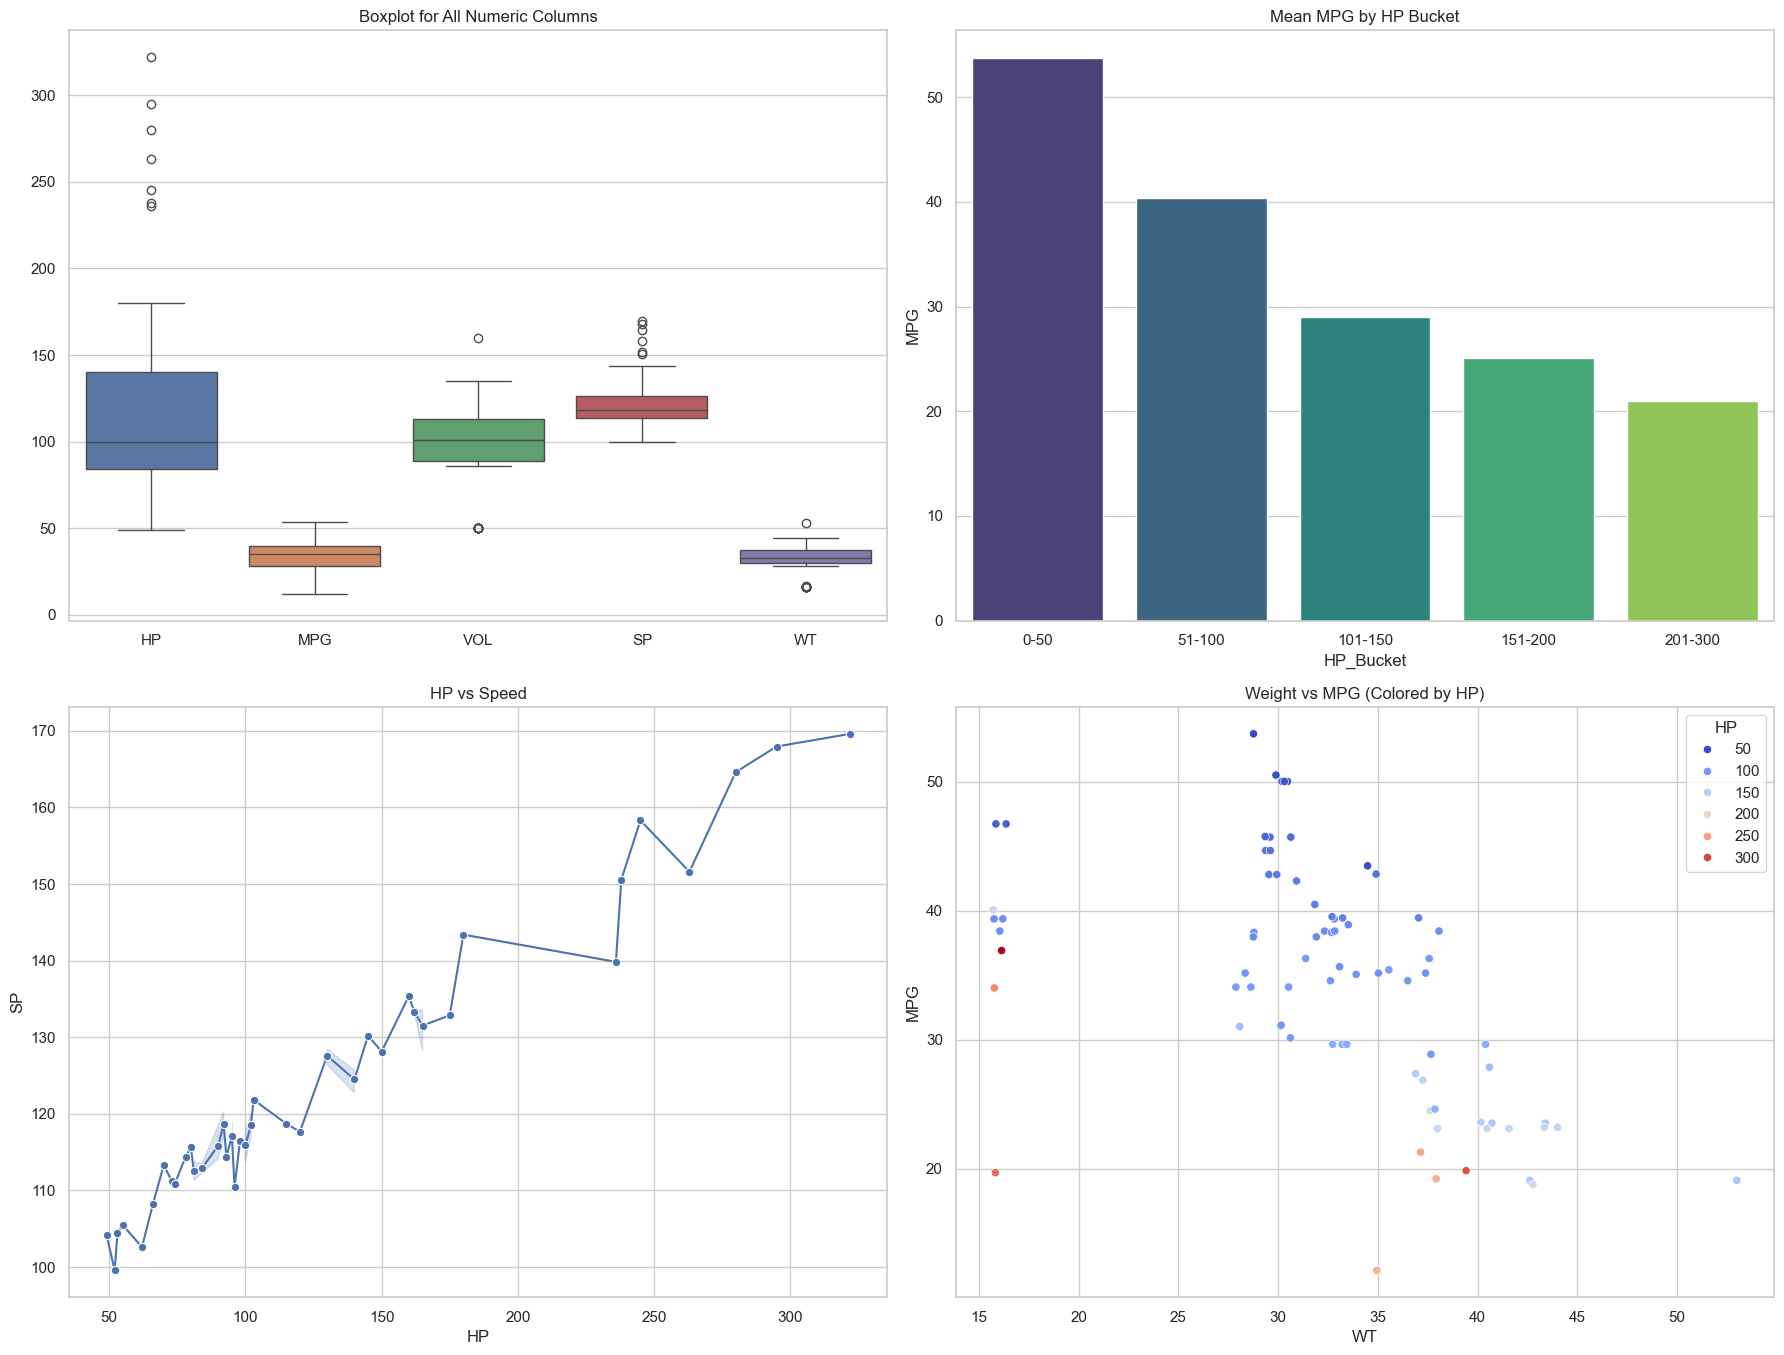

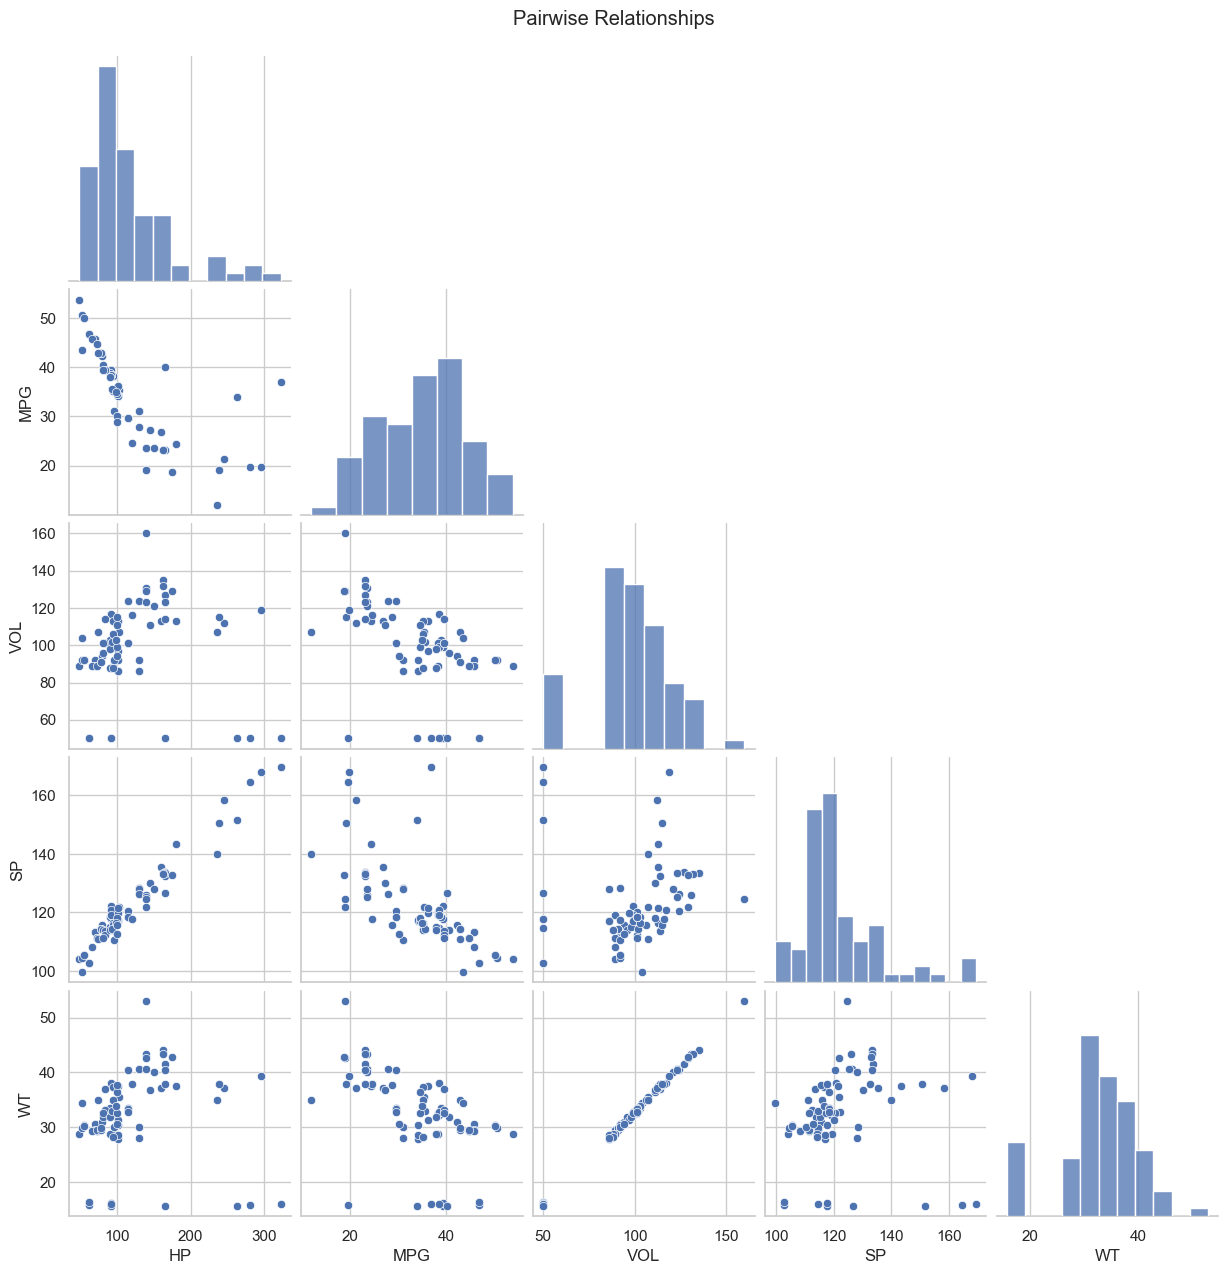

In [14]:
#Visulizations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Cars.csv")

# Set seaborn style
sns.set(style="whitegrid")

# Create figure for subplots
plt.figure(figsize=(18, 20))

# 1. Boxplot for each numeric column
plt.subplot(3, 2, 1)
sns.boxplot(data=df)
plt.title("Boxplot for All Numeric Columns")

# 2. Barplot: Mean MPG per HP bucket
df['HP_Bucket'] = pd.cut(df['HP'], bins=[0, 50, 100, 150, 200, 300], labels=['0-50', '51-100', '101-150', '151-200', '201-300'])
mpg_by_hp = df.groupby('HP_Bucket')['MPG'].mean().reset_index()

plt.subplot(3, 2, 2)
sns.barplot(x='HP_Bucket', y='MPG', data=mpg_by_hp, palette='viridis')
plt.title("Mean MPG by HP Bucket")

# 3. Line plot: HP vs SP
df_sorted = df.sort_values('HP')
plt.subplot(3, 2, 3)
sns.lineplot(x='HP', y='SP', data=df_sorted, marker="o")
plt.title("HP vs Speed")

# 4. Scatter plot: Weight vs MPG
plt.subplot(3, 2, 4)
sns.scatterplot(x='WT', y='MPG', data=df, hue='HP', palette='coolwarm')
plt.title("Weight vs MPG (Colored by HP)")

# 5. Pairplot: All numeric relationships
# Plotting separately as it generates its own figure
plt.tight_layout()
plt.show()

sns.pairplot(df[['HP', 'MPG', 'VOL', 'SP', 'WT']], corner=True)
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()
